# Assignment: Try to segment foreground objects from the background

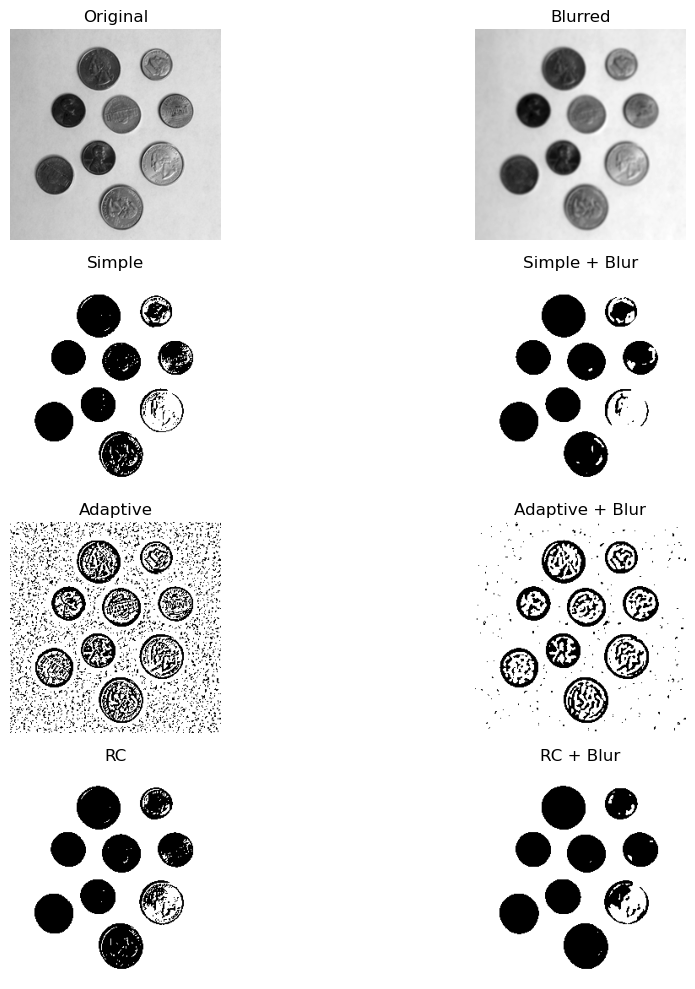

In [3]:
import cv2
import numpy as np
import mahotas
import matplotlib.pyplot as plt

# 載入圖片
image = cv2.imread("coins.png", cv2.IMREAD_GRAYSCALE)

# 模糊處理
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# ===== 1. Simple Thresholding =====
_, simple = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
_, simple_blur = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# ===== 2. Adaptive Thresholding =====
adaptive = cv2.adaptiveThreshold(
    image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2)

adaptive_blur = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2)

# ===== 3. Ridler-Calvard Thresholding =====
T_RC = mahotas.thresholding.rc(blurred)
rc = image.copy()
rc[rc > T_RC] = 255
rc[rc <= T_RC] = 0

rc_blur = blurred.copy()
rc_blur[rc_blur > T_RC] = 255
rc_blur[rc_blur <= T_RC] = 0

# ===== 視覺化比較 =====
titles = [
    "Original", "Blurred",
    "Simple", "Simple + Blur",
    "Adaptive", "Adaptive + Blur",
    "RC", "RC + Blur"
]
images = [
    image, blurred,
    simple, simple_blur,
    adaptive, adaptive_blur,
    rc, rc_blur
]

plt.figure(figsize=(12, 10))
for i in range(len(images)):
    plt.subplot(4, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


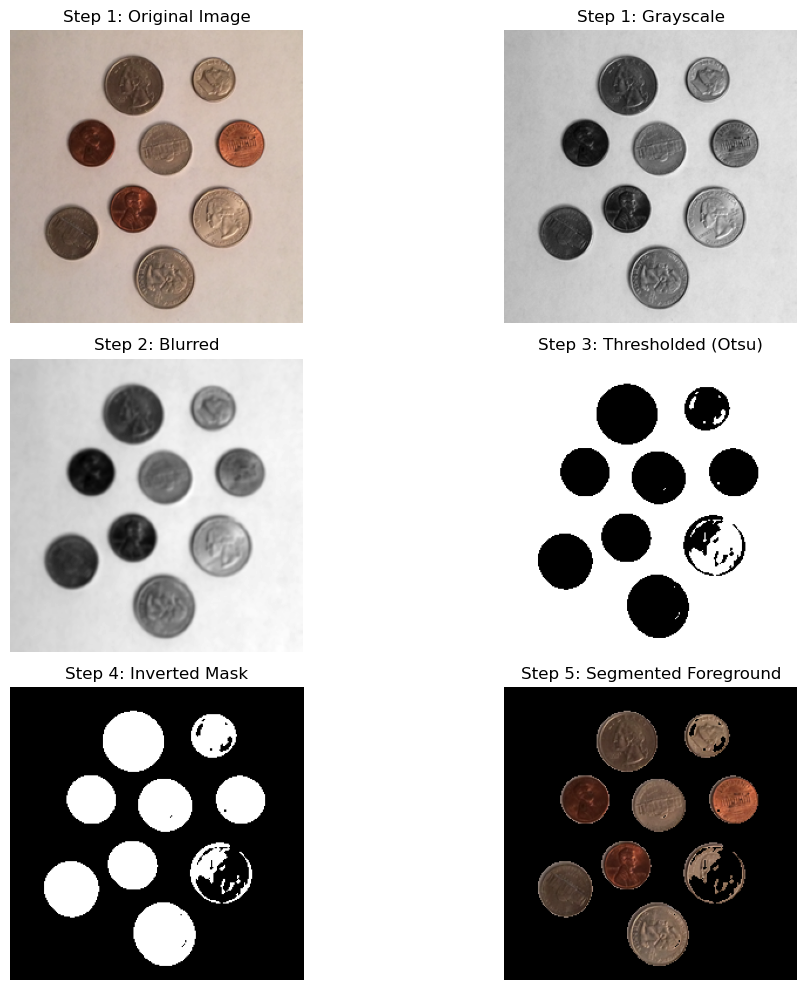

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 載入並灰階化圖片
image = cv2.imread("coins.png")
if image is None:
    raise ValueError("⚠️ 圖片讀取失敗，請確認 'your_image.jpg' 是否存在於程式同一資料夾")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: 高斯模糊 (去除雜訊)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 3: Otsu 閾值處理
_, thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Step 4: 建立反向遮罩 (讓前景變白)
mask_inv = cv2.bitwise_not(thresh)

# Step 5: 利用遮罩取得前景
foreground = cv2.bitwise_and(image, image, mask=mask_inv)

# Step 6: 顯示所有步驟的圖片
titles = [
    "Step 1: Original Image",
    "Step 1: Grayscale",
    "Step 2: Blurred",
    "Step 3: Thresholded (Otsu)",
    "Step 4: Inverted Mask",
    "Step 5: Segmented Foreground"
]

images = [
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    gray,
    blurred,
    thresh,
    mask_inv,
    cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)
]

plt.figure(figsize=(12, 10))
for i in range(len(images)):
    plt.subplot(3, 2, i + 1)
    if len(images[i].shape) == 2:  # 灰階圖片
        plt.imshow(images[i], cmap='gray')
    else:  # 彩色圖片
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [19]:
T_otsu, thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"Otsu Threshold SELECT {T_otsu}")


Otsu Threshold SELECT 137.0
